# Cameras comparison.
This notebook establishes a rigorous analytical framework to evaluate and compare the performance of scientific-grade cameras (CCD, EMCCD, qCMOS) integrated into our dual-line cold-atom experimental apparatus. By coupling a trapping line ($\lambda_{\mathrm{trap}} = 850\text{ nm}$) and a fluorescence imaging line ($\lambda_{\mathrm{fluo}} = 780\text{ nm}$) through a shared atomic plane, the optical design geometrically constrains both collection efficiency and spatial resolution. To benchmark candidate sensors for high-fidelity state readout of $^{87}\text{Rb}$ atoms in optical tweezers, we systematically model the transformation of isotropic atomic emission into a localized photon flux per pixel, factoring in the numerical aperture of the collection objective and the magnification of the relay-tube lens subsystem.

The evaluation workflow progresses from fundamental photon-budget estimation to predictive sensor benchmarking. We first quantify the expected photon flux incident on the sensor matrix during a typical exposure window, incorporating atomic scattering rates and system transmission losses. Next, we model the intrinsic noise mechanisms of modern photosensors—including read noise, dark current, clock-induced charge, and quantum efficiency variations—to map how these parameters govern the Signal-to-Noise Ratio (SNR). This SNR is directly mapped to the statistical discriminability between the presence ("1") and absence ("0") of an atom, visually characterized by the overlap of their respective Poissonian and Gaussian probability density functions. Finally, we generate comparative SNR curves across a sweep of realistic photon fluxes, providing a deterministic criteria to select the optimal camera capable of maximizing detection fidelity while minimizing readout-induced errors.

## Photon emission estimation.

To establish a rigorous and realistic signal baseline, we model the total number of photons emitted by a single $^{87}\text{Rb}$ atom within the optical tweezer. Unlike ideal models where the scattering rate asymptotically approaches $\Gamma / 2$, the emission in a tight optical trap is fundamentally constrained by the geometry of the trapping line and the operational limits of the Magneto-Optical Trap $\left(\text{MOT}\right)$ cooling lasers. The numerical aperture $\left(\text{NA}\right)$ of the objective defines the diffraction-limited beam waist $\left(w_0\right)$ of the trapping laser $\left(\lambda_{\mathrm{trap}} = 850\text{ nm}\right)$ according to the optical relation:

$$w_0 \simeq \frac{\lambda_{\mathrm{trap}}}{\pi \cdot \text{NA}}$$

The spatial confinement dictated by the $\text{NA}$ directly governs the local intensity profile at the center of the trap. For a fixed trapping laser power $P$, the peak intensity $I_{\mathrm{trap}}$ scales inversely with the square of the beam waist, generating a localized potential depth $U_0$ that can be expressed as:

$$I_{\mathrm{trap}} = \frac{2P}{\pi w_0^2} \Rightarrow U_0 \propto I_{\mathrm{trap}} \propto \frac{P \cdot \text{NA}^2}{\lambda_{\mathrm{trap}}^2}$$

While a higher potential depth is crucial for robust atomic confinement, it simultaneously induces a substantial differential AC Stark shift $\left(\text{light-shift}\right)$ on the atomic levels. This localized shift displaces the resonance frequency of the $D_2$ transition $\left(5^{2}\text{S}_{\tfrac{1}{2}} \rightarrow 5^{2}\text{P}_{\tfrac{3}{2}}\text{, where }\Gamma \simeq 2\pi\cdot 6.065 \text{ MHz}\right)$, pushing the atom out of resonance with the MOT beams. The resulting effective detuning $\left(\Delta_{\mathrm{eff}}\right)$ combines the nominal red-detuning of the MOT lasers $\left(\Delta_{\mathrm{laser}}\right)$ and the trap-induced light-shift $\left(\Delta_{\mathrm{shift}}\right)$:

$$\Delta_{\mathrm{eff}} = \Delta_{\mathrm{laser}} + \Delta_{\mathrm{shift}}$$

This effective detuning heavily suppresses the excitation efficiency driven by the MOT. To prevent severe Doppler heating and maintain single-atom loading, the MOT cooling lasers must operate under strictly low-intensity regimes, fundamentally limiting their available scattering parameter $\left(I/I_{\mathrm{sat}}\right)$. Following the framework for single-atom regimes in optical tweezers, this constraint combined with the off-resonance condition defines the effective saturation parameter $\left(s_{\mathrm{eff}}\right)$ as:

$$s_{\mathrm{eff}} = \frac{I/I_{\mathrm{sat}}}{1 + 4\left(\frac{\Delta_{\mathrm{eff}}}{\Gamma}\right)^2}$$

Consequently, the effective photon scattering rate $\left(R_{\mathrm{scat}}\right)$ scales downstream from the geometric and thermodynamic constraints of the system, yielding:

$$R_{\mathrm{scat}} = \frac{\Gamma}{2} \frac{s_{\mathrm{eff}}}{1 + s_{\mathrm{eff}}}$$

Accounting for the conservation of optical etendue within our apparatus, the system operates across a definitive range bounded between $\text{NA} = 0.28$ and $\text{NA} = 0.65$. This geometric sweep establishes two distinct physical regimes for our photon budget:

* **Low-NA Regime $\left(\text{NA} = 0.28\right)$:** The larger beam waist $\left(w_0 \simeq 1.0\ \mu\text{m}\right)$ restricts the local intensity, bounding the light-shift to a few MHz. The effective detuning remains low, keeping the system closer to resonance. Under these conditions, the effective saturation parameter rises to $s_{\mathrm{eff}} \simeq 0.25$, maximizing the emission rate up to $R_{\mathrm{scat}} \simeq 5\cdot 10^6 \text{ photons/s}$

* **High-NA Regime $\left(\text{NA} = 0.65\right)$:** The sub-micron beam waist $\left(w_0 \simeq 0.4\ \mu\text{m}\right)$ scales the local intensity by a factor of five, driving a deep potential well. This intense light-shift pushes the effective detuning toward $\Delta_{\mathrm{eff}} \simeq 55 \text{ MHz}$. As a result, the excitation is heavily suppressed, dropping the effective saturation parameter to $s_{\mathrm{eff}} \simeq 0.05$ and restricting the scattering rate to $R_{\mathrm{scat}} \simeq 1\cdot 10^6 \text{ photons/s}$

### Geometric collection efficiency.

In an experimental setup, cold Rubidium atoms trapped at the focal plane emit fluorescence light isotropically over a full sphere ($4\pi$ steradians). The collection objective acts as a geometric spatial aperture that captures only a solid angle cone of this total emission. The half-acceptance angle $\theta$ of this light cone is fundamentally defined by the nominal numerical aperture of the medium (where $n=1$ in vacuum):

$$\mathrm{NA} = \sin\theta$$

By integrating the differential solid angle element over this cone of acceptance from the optical axis out to the marginal ray boundary, we find the captured solid angle $\Omega$:

$$\Omega = \int_{0}^{2\pi} d\phi \int_{0}^{\theta} \sin\theta' d\theta' = 2\pi \left( 1 - \cos\theta \right)$$

Substituting the identity $\cos\theta = \sqrt{1 - \sin^2\theta} = \sqrt{1 - \mathrm{NA}^2}$ into the solid angle expression yields:

$$\Omega = 2\pi \left( 1 - \sqrt{1 - \mathrm{NA}^2} \right)$$

Dividing this captured solid angle by the full $4\pi$ steradians of a sphere defines the geometric photon collection efficiency $\eta$. This ratio represents the absolute upper bound of our photon budget entering the optical line before accounting for surface transmission coatings or sensor quantum efficiency:

$$\eta_{\text{col}} = \frac{\Omega}{4\pi} = \frac{1 - \sqrt{1 - \mathrm{NA}^2}}{2} \simeq 0.12$$

### Optical transmission losses.

To transition from an idealized geometric model to the empirical reality of the laboratory optical train, we must quantify the deterministic attenuation introduced by the physical optics. The fluorescence detection line routes the $\lambda_{\mathrm{fluo}} = 780\text{ nm}$ photons through several loss mechanisms, including internal absorption within the objective, surface back-reflections across the relay optics, and spectral filtering components.

The collection optics utilize a custom multi-element objective whose complex internal lens architecture inherently introduces losses. For our operating wavelength, the net internal transmission efficiency is evaluated at $\eta_{\mathrm{obj}} \simeq 0.87$. Following the objective, the transmission line incorporates several key elements:

* **Dichroic mirror:** Essential for separating the trapping line $\left(850\text{ nm}\right)$ from the fluorescence line $\left(780\text{ nm}\right)$, with a typical reflection/transmission efficiency of $\eta_{\mathrm{dichroic}} \simeq 0.90$.
* **Interference filter:** A narrow band-pass filter centered at $780\text{ nm}$ is placed before the sensor to suppress background noise from the trapping laser and ambient light, contributing an efficiency of $\eta_{\mathrm{filter}} \simeq 0.90$.
* **Relay optics:** The transmission line consists of a relay telescope and a tube lens, accumulating a total of $N = 6$ air-glass interfaces. Each surface is treated with high-performance broadband anti-reflective coatings, restricting reflection losses to $R \le 0.01$ per surface.

Combining the internal objective throughput, the spectral filtering stages, and the multi-surface Fresnel transmission, the net cumulative optical transmission efficiency $\eta_{\mathrm{trans}}$ is defined as:

$$\eta_{\mathrm{trans}} = \eta_{\mathrm{obj}} \cdot \eta_{\mathrm{dichroic}} \cdot \eta_{\mathrm{filter}} \cdot \left( 1 - R \right)^N \simeq 0.66$$

### Photon number estimation.

To establish the definitive predictive framework for our sensor benchmarking, we synthesize the atomic scattering rates, cumulative optical losses, and spatial profiling factors. This allows us to map the microscopic emission down to the observable number of photons collected by a single primary pixel as a explicit function of the experimental integration time ($t_{\mathrm{exp}}$).

By combining the fixed geometric collection efficiency ($\eta_{\mathrm{geom}} \simeq 0.12$) and the net cumulative optical transmission throughput ($\eta_{\mathrm{trans}} \simeq 0.66$), the total optical system efficiency ($\eta_{\mathrm{tot}}$) before striking the sensor matrix is established as:

$$\eta_{\mathrm{tot}} = \eta_{\mathrm{geom}} \cdot \eta_{\mathrm{trans}} \simeq 0.12 \cdot 0.66 \simeq 0.079 \Rightarrow R_{\mathrm{scat}}^{\mathrm{eff}} \simeq 0.079 \cdot 10^6 \text{ photons/s} \sim 8 \cdot 10^4 \text{ photons/s}$$

For example, if one takes 

$$t_{\mathrm{exp}} = 10 \text{ ms} \Rightarrow N_{\mathrm{photons}} \sim 8 \cdot 10^4 \text{ photons/s} \cdot 10\cdot10^{-3} \text{ s} \sim 800 \text{ photons}$$

In [2]:
# Import required external libraries
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# -----------------------------------------------------------------------------
# Physical & experimental constants
# -----------------------------------------------------------------------------

# Atomic constants for Rubidium-87 (D2 line transition)
gamma_rb87 = 2 * np.pi * 6.065e6  # Natural linewidth in rad/s (6.065 MHz)
wavelength_fluo = 780e-9  # Fluorescence wavelength in meters (780 nm)

# User-defined experimental and execution parameters
exposure_time = 10e-3  # Integration window in seconds (10 ms)
magnification = 5.0  # Lateral optical magnification of the imaging system

# -----------------------------------------------------------------------------
# optical system & transmission efficiency
# -----------------------------------------------------------------------------

# Collection optics and transmission line specifications
na_col = 0.65  # Numerical aperture of the collection objective
eta_obj = 0.87  # Internal transmission efficiency of the objective
eta_dichroic = 0.90  # Transmission efficiency of the dichroic beam splitter
eta_filter = 0.90  # Transmission efficiency of the interference filter
coating_reflection = 0.01  # Reflection loss per air-glass interface (1%)
num_surfaces = 6  # Total air-glass interfaces (relay and tube lenses)

# Magneto-Optical Trap (MOT) cooling laser parameters
i_over_isat = 1.6  # Laser intensity parameter relative to saturation (I / I_sat)
delta_laser = -2 * np.pi * 12e6  # Red-detuning of the laser in rad/s (-12 MHz)

# Geometric collection efficiency based on solid angle
eta_geom = (1 - np.sqrt(1 - na_col**2)) / 2

# Net optical transmission efficiency through the optical path
eta_trans = (
    eta_obj
    * eta_dichroic
    * eta_filter
    * ((1 - coating_reflection) ** num_surfaces)
)

# Total overall detection efficiency
eta_tot = eta_geom * eta_trans

# -----------------------------------------------------------------------------
# Fluorescence calculations & regime comparison
# -----------------------------------------------------------------------------

# Analytical execution loop across light-shift trapping regimes
for regime_name, delta_shift in [
    ("LOW NA_trap (0.28) - Near resonance", 2 * np.pi * 4e6),  # Small light-shift (4 MHz)
    ("HIGH NA_trap (0.65) - Deep light-shift", 2 * np.pi * 55e6),  # Deep light-shift (55 MHz)
]:
    # Calculate effective detuning, saturation parameter, and scattering rate
    delta_eff = delta_laser + delta_shift
    s_eff = i_over_isat / (1 + 4 * (delta_eff / gamma_rb87) ** 2)
    r_scat = (gamma_rb87 / 2) * (s_eff / (1 + s_eff))

    # Calculate total photon counts
    total_emitted = r_scat * exposure_time
    total_collected = total_emitted * eta_tot

    # Display computed experimental metrics per regime
    print(f"================================================================")
    print(f" TRAPPING REGIME: {regime_name}")
    print(f"================================================================")
    print(f"Exposure time (t_exp):                {exposure_time*1e3} ms")
    print(f"Effective detuning (Delta_eff):       {delta_eff / (2*np.pi*1e6):.2f} MHz")
    print(f"Calculated saturation (s_eff):        {s_eff:.4f}")
    print(f"Effective scattering rate:            {r_scat:.2e} photons/s")
    print(f"Total photons emitted by the atom:    {total_emitted:.2e}")
    print(f"Expected photons incident on sensor:  {total_collected:.1f} photons\n")

 TRAPPING REGIME: LOW NA_trap (0.28) - Near resonance
Exposure time (t_exp):                10.0 ms
Effective detuning (Delta_eff):       -8.00 MHz
Calculated saturation (s_eff):        0.2010
Effective scattering rate:            3.19e+06 photons/s
Total photons emitted by the atom:    3.19e+04
Expected photons incident on sensor:  2539.7 photons

 TRAPPING REGIME: HIGH NA_trap (0.65) - Deep light-shift
Exposure time (t_exp):                10.0 ms
Effective detuning (Delta_eff):       43.00 MHz
Calculated saturation (s_eff):        0.0079
Effective scattering rate:            1.50e+05 photons/s
Total photons emitted by the atom:    1.50e+03
Expected photons incident on sensor:  119.2 photons



## SNR estimation.

The detection of a single trapped atom via fluorescence imaging is fundamentally a binary hypothesis testing problem. We define two competing operational states: the null hypothesis $H_0$, representing an empty optical tweezer where the registered signal consists of sensor-induced noise and a proportional photon background flux arising from stray laser scattering; and the alternative hypothesis $H_1$, representing the presence of a single $^{87}\text{Rb}$ atom contributing an additional fluorescence photon flux ($N_{\mathrm{photons}}$). In the raw physical histogram, these hypotheses manifest as a bimodal distribution. After accounting for experimental background subtraction protocols, the net signal baseline to be discriminated ($\Delta\mu$) is driven exclusively by the atomic fluorescence. However, the stochastic nature of the background photons injects an irreversible quantum shot noise channel that broadens the probability distributions of both states, fundamentally altering the noise landscape.

Instead of an idealized zero-background model or an isolated single-state metric, the Signal-to-Noise Ratio ($\mathrm{SNR}$) is rigorously defined as the ratio between the net expected mean signal generated by the atom ($S_{\text{net}}$) and the total standard deviation of the system ($\sigma_{\text{total}}$):

$$\mathrm{SNR} = \frac{S_{\text{net}}}{\sigma_{\text{total}}}$$

Under this definition, maximizing the $\mathrm{SNR}$ directly dictates the statistical discriminability between the two states. A higher $\mathrm{SNR}$ implies that the distribution peaks are significantly narrower relative to their mutual separation, compressing their respective widths ($\sigma_0, \sigma_1$) and drastically reducing the physical overlap between the histograms of $H_0$ and $H_1$. In single-atom experiments, minimizing this overlap is essential to avoid state-readout errors—such as false positives (counting an atom due to a noise fluctuation in an empty trap) or false negatives (missing an atom due to a low photon count). Achieving a high $\mathrm{SNR}$ ensures that a clean threshold value of digital counts can perfectly separate the bimodal distribution, guaranteeing high-fidelity atom discrimination.

To construct the total noise envelope $\sigma_{\text{total}}$, we exploit a fundamental property of probability theory: for mutually independent random variables, the variance of their sum is strictly equal to the sum of their individual variances. In our imaging system, the underlying noise channels—such as atomic photon shot noise ($X_{\text{shot}}$), background photon shot noise ($X_{\text{bg}}$), dark current fluctuations ($X_{\text{dark}}$), and electronic read noise ($X_{\text{read}}$)—stem from uncorrelated microscopic and electronic processes. Because these physical mechanisms are statistically independent, their covariances vanish. Consequently, the total standard deviation $\sigma_{\text{total}}$ governing any given sensor architecture can be computed directly as the quadrature sum of its independent noise components:

$$\sigma_{\text{total}} = \sqrt{\sigma_{\text{shot}}^2 + \sigma_{\text{bg}}^2 + \sigma_{\text{dark}}^2 + \sigma_{\text{read}}^2}$$

To map this mathematical model into our quantitative numerical execution, the environmental noise channels are parameterized as fractional components of the total incident photon flux ($N_{\mathrm{photons}}$). Following empirical single-atom benchmarks—such as those established in Lucas Béguin's thesis regarding stray laser scattering against sub-vacuum lens holders—the background noise floor and the thermal dark current scale downstream from the primary signal through a background fraction coefficient ($f_{\mathrm{bg}}\sim\frac{10^3}{10^6}=10^{-3}$) and a dark fraction coefficient ($f_{\mathrm{dark}}\sim \frac{10^{-2}}{10^6}=10^{-8}$). Furthermore, to prevent unphysical predictions at high photon fluxes, the analytical framework enforces a hard saturation threshold governed by the sensor's physical Full Well Capacity. If the local charge per single pixel or the aggregated register charge exceeds these operational limits ($Q_{\text{pixel}} \ge Q_{\text{FW, pix}}$ or $Q_{\text{register}} \ge Q_{\text{FW, reg}}$), the signal is masked as mathematically invalid ($\mathrm{NaN}$), mapping the deterministic breakdown of the linear sensor response.

### Charge-Coupled Devices (CCD).

The Charge-Coupled Device (CCD) represents the foundational architecture for scientific-grade digital imaging. In a CCD sensor, the physical detection mechanism is based on the photoelectric effect within a continuous matrix of potential wells embedded in a silicon substrate. When fluorescence photons from the $^{87}\text{Rb}$ atoms strike the active area, they generate electron-hole pairs. These photo-electrons are locally trapped within the electrostatic boundaries of each individual pixel throughout the integration window.

The defining characteristic of a CCD is its sequential readout mechanism. Once the exposure window concludes, the stored electronic charges are not converted to digital counts locally. Instead, the sensor applies parallel vertical clock voltages to shift the entire row configuration downward, transferring the charge packets line-by-line into a horizontal shift register. From there, the charges are moved serially, pixel-by-pixel, toward a single, isolated reading cell located at the corner of the chip. This single-node architecture guarantees excellent uniformity across the entire image profile since every pixel shares the exact same electronic conversion path. However, it imposes a strict bottleneck on readout speed, as high frame rates force the amplifier to operate at frequencies that inherently elevate electronic noise.

To derive the total noise envelope $\sigma_{\text{CCD}}$ governing a CCD architecture, we evaluate the statistically independent physical mechanisms that degrade the signal quality during the exposure and readout phases, explicitly incorporating the fractional noise channels modeled in our quantitative numerical execution across an array of binned pixels ($N_{\mathrm{bin}}^2$):

* **Atomic photon shot noise ($\sigma_{\text{shot}}^2$):** This noise is intrinsic to the quantum nature of light and follows Poissonian statistics, meaning its variance is strictly equal to the mean number of successfully generated photo-electrons from atomic fluorescence: $\sigma_{\text{shot}}^2 = \eta_q \cdot N_{\mathrm{photons}}$.
* **Background photon shot noise ($\sigma_{\text{bg}}^2$):** The stray laser scattering collected by the active area scales with the background fraction ($f_{\mathrm{bg}}$) and the total number of grouped elements, contributing an additional Poissonian variance of: $\sigma_{\text{bg}}^2 = \eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2$.
* **Dark current noise ($\sigma_{\text{dark}}^2$):** Spontaneous thermal excitations within the silicon substrate scale proportionally to the incident flux distribution through the dark fraction coefficient ($f_{\mathrm{dark}}$) and expand with the super-pixel area, yielding a variance of: $\sigma_{\text{dark}}^2 = N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2$.
* **Electronic read noise ($\sigma_{\text{read}}^2$):** This noise channel is injected purely during the charge-to-voltage conversion at the single reading cell. Because the CCD architecture shifts and combines the analog charge packets within the registers prior to digitization, this constant Gaussian noise floor ($\sigma_{\text{read}}$, expressed in $e^{-}$ RMS) is added only once per readout cycle.

The net signal $S$ extracted after background subtraction protocols is governed by the quantum efficiency ($\eta_q$) of the sensor:

$$S = \eta_q \cdot N_{\mathrm{photons}}$$

The total variance $\sigma_{\text{CCD}}^2$ summing the uncorrelated atomic shot noise, binned background shot noise, binned dark current noise, and single-node read noise is formulated as:

$$\sigma_{\text{CCD}}^2 = (\eta_q \cdot N_{\mathrm{photons}}) + (\eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2) + (N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2) + \sigma_{\text{read}}^2$$

Taking the ratio of the net atomic mean signal to the total standard deviation yields the definitive equation for the Signal-to-Noise Ratio of a standard CCD camera, as implemented in our computational benchmark (`calculate_ccd_snr`):

$$\mathrm{SNR}_{\text{CCD}} = \frac{\eta_q \cdot N_{\mathrm{photons}}}{\sqrt{\eta_q \cdot N_{\mathrm{photons}} + \eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2 + N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2 + \sigma_{\text{read}}^2}}$$

### Electron-Multiplied CCD (EMCCD).

The Electron-Multiplied CCD (EMCCD) was developed specifically to overcome the electronic read noise floor that severely limits standard CCDs in ultra-low-light applications, such as single-atom fluorescence imaging. The physical architecture of an EMCCD is highly analogous to a standard CCD, but it introduces a critical modification: an extended solid-state multiplication register positioned between the horizontal shift register and the final output video amplifier. 

Within this multiplication register, the columns are driven by significantly higher clock voltages. As photo-electrons are shifted sequentially through these stages, they experience high local electrostatic fields, accelerating them to kinetic energies sufficient to trigger impact ionization within the silicon crystal lattice. This process generates secondary electrons, effectively creating an amplification cascade governed by a user-defined gain factor $G$. By multiplying the electronic charge packet *before* it encounters the single output amplifier, the effective electronic read noise is camouflaged, scaling down in the signal domain as $\sigma_{\text{read}}/G$. When $G \gg \sigma_{\text{read}}$, the electronic noise floor effectively drops below $1\ e^{-}$, enabling single-photon sensitivity.

Despite its ability to bypass read noise, the impact ionization mechanism is fundamentally a probabilistic, stochastic process. Each electron entering the multiplication register has a specific probability—rather than a deterministic guarantee—of generating a secondary electron at each stage. This statistical uncertainty introduces macroscopic fluctuations in the output signal, a phenomenon quantified by the excess noise factor ($F$). For high gain coefficients, this factor asymptotically approaches $F \simeq \sqrt{2} \simeq 1.414$. In terms of variance, the shot noise of the incoming signal is effectively doubled ($F^2 \simeq 2$), meaning that while the electronic noise floor is bypassed, the statistical uncertainty of the captured photon budget is significantly penalized.

Furthermore, the high-voltage clock pulses required to drive this impact ionization introduce a unique noise channel known as Clock-Induced Charge (CIC). The rapid, high-amplitude transitions of the potential wells can spontaneously isolate and excite valence electrons into the conduction band, even at cryogenic temperatures. These spurious electrons are generated during the clocking phase and are visually indistinguishable from true photo-electrons. Because CICs ($\sigma_{\mathrm{CIC}}$), binned dark current electrons, and binned background photons are all generated or collected within the pixel matrix *prior* to entering the multiplication register, they experience the exact same stochastic amplification cascade as the atomic signal. Consequently, their mean values are multiplied by $G$, and their statistical variances are amplified by both the gain squared ($G^2$) and the excess noise factor squared ($F^2$).

Accounting for the gain amplification, the uncorrelated noise channels, and the environmental background, the mean amplified signal measured at the output amplifier in electron counts under the alternative hypothesis $H_1$ is scaled by $G$. However, after experimental background subtraction protocols, the net atomic mean signal $S$ remains isolated in the numerator as:

$$S = G \cdot \eta_q \cdot N_{\mathrm{photons}}$$

By applying the linearity of variance, the total noise variance $\sigma_{\text{EMCCD}}^2$ at the output amplifier must incorporate the $F^2 \cdot G^2$ penalty on all pre-amplified components—including the binned background shot noise, the binned dark current, and the binned clock-induced charge—alongside the unamplified read noise floor added at the final stage. This matches the exact formulation implemented in our computational benchmark (`calculate_emccd_snr`):

$$\sigma_{\text{EMCCD}}^2 = G^2 \cdot F^2 \cdot \left(\eta_q \cdot N_{\mathrm{photons}} + \eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2 + N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2 + \sigma_{\mathrm{CIC}} \cdot N_{\mathrm{bin}}^2\right) + \sigma_{\text{read}}^2$$

Dividing the net mean amplified signal by the total standard deviation yields the definitive closed-form equation for the Signal-to-Noise Ratio of an EMCCD camera under realistic, binned experimental conditions:

$$\mathrm{SNR}_{\text{EMCCD}} = \frac{G \cdot \eta_q \cdot N_{\mathrm{photons}}}{\sqrt{G^2 \cdot F^2 \cdot \left(\eta_q \cdot N_{\mathrm{photons}} + \eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2 + N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2 + \sigma_{\mathrm{CIC}} \cdot N_{\mathrm{bin}}^2\right) + \sigma_{\text{read}}^2}}$$

### Scientific Complementary Metal-Oxide-Semiconductor (sCMOS).

The architecture of scientific Complementary Metal-Oxide-Semiconductor (sCMOS) sensors introduces a fundamental paradigm shift from the sequential readout of CCDs by distributing the charge-to-voltage conversion across the pixel matrix. In an sCMOS sensor, every single pixel column features its own dedicated amplifier and Analog-to-Digital Converter (ADC). This massively parallel processing architecture allows entire rows to be read simultaneously, driving frame rates to hundreds of hertz while bypassing the bandwidth bottlenecks that plague single-amplifier CCDs. However, because each pixel possesses an independent electronic readout chain, classical sCMOS sensors suffer from a read noise floor that typically stagnates around $1.0\text{--}1.5\ e^{-}$ RMS, which is insufficient for noise-free single-photon resolving.

To bridge the gap between the high speed of CMOS and the single-photon sensitivity of EMCCDs, Quantitative CMOS (qCMOS) technology minimizes the physical area of the floating diffusion node within each individual pixel. By suppressing the parasitic capacitance ($C$), the voltage change per individual electron is drastically enhanced according to the relation $\Delta V = \frac{\Delta Q}{C}$. This maximizes the charge conversion gain at the pixel level, pushing the electronic signal far above the thermal noise floor of the readout transistors.

As a direct consequence of this design, qCMOS sensors achieve an unprecedented sub-electron read noise floor, scaling down to $\sigma_{\text{read}} \sim 0.2\text{--}0.3\ e^{-}$ RMS, which enables a strict single-photon counting regime. Because this sensitivity is achieved through passive electronic noise suppression rather than an active stochastic multiplication cascade, the Excess Noise Factor is strictly unity ($F = 1$). Consequently, qCMOS sensors deliver ultra-low-noise detection capabilities without doubling the photon shot noise variance, while providing high quantum efficiency ($\eta_q$) at our target atomic fluorescence line.

In a qCMOS architecture, the net electronic signal $S$ extracted after background subtraction protocols follows the linear conversion of the incident photon flux over the exposure window without any gain-induced scaling:

$$S = \eta_q \cdot N_{\mathrm{photons}}$$

By utilizing the linearity of variance for independent processes, the total noise variance $\sigma_{\text{qCMOS}}^2$ must encompass the unamplified atomic shot noise, the binned background shot noise, and the binned dark current channels. Furthermore, because CMOS architectures digitize the signal locally before any grouping can occur, software-level aggregation forces the independent read noise variances of every individual pixel inside the cluster to sum in quadrature, yielding:

$$\sigma_{\text{qCMOS}}^2 = (\eta_q \cdot N_{\mathrm{photons}}) + (\eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2) + (N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2) + (\sigma_{\text{read}}^2 \cdot N_{\mathrm{bin}}^2)$$

Dividing the net mean signal by the total standard deviation yields the definitive closed-form equation for the Signal-to-Noise Ratio of a qCMOS camera under realistic experimental conditions, matching the exact implementation of our computational model (`calculate_qcmos_snr`):

$$\mathrm{SNR}_{\text{qCMOS}} = \frac{\eta_q \cdot N_{\mathrm{photons}}}{\sqrt{\eta_q \cdot N_{\mathrm{photons}} + \eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2 + N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2 + \sigma_{\text{read}}^2 \cdot N_{\mathrm{bin}}^2}}$$

While this mathematical formulation structural resembles a standard CCD, the physical parameters differ fundamentally. The sub-electron nature of the read noise paired with a high quantum efficiency $\eta_q$ ensures that the $\mathrm{SNR}_{\text{qCMOS}}$ remains strictly shot-noise limited even at ultra-low photon counts, making it the optimal technological selection for our experimental single-atom fluorescence imaging setup.

### Impact of pixel binning and spatial distribution.

To maximize photon collection from the diffraction-limited spot or to shield the state-readout workflow against stochastic spatial drifting, pixel binning (typically $2\times2$ or $3\times3$ arrays) is frequently implemented. This operational strategy aggregates a cluster of $N_{\mathrm{bin}} \times N_{\mathrm{bin}}$ physical pixels into a single logical "super-pixel." While this spatial integration effectively expands the integration boundaries, it fundamentally reshapes the scaling laws of both the environmental background noise and the internal electronic noise propagation.

Because the stray light that constitutes the background flux is uniformly distributed across the sensor matrix, a binned super-pixel sweeps a larger physical area, capturing a linearly scaled background and dark current footprint. In our analytical model, these channels scale directly with the number of grouped elements ($N_{\mathrm{bin}}^2$), injecting amplified noise variances ($\sigma_{\text{bg, bin}}^2 = \eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2$ and $\sigma_{\text{dark, bin}}^2 = N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2$). 

The ultimate impact of binning on the global $\text{SNR}$ equations is dictated by the underlying sensor architecture, establishing a strict dichotomy based on when and where the charge digitization occurs:

* **Hardware-level binning (CCD and EMCCD):** In charge-coupled architectures, the accumulated electronic charges from the constituent pixels are shifted and combined within the analog registers *before* reaching the output node. Therefore, the total combined signal and its expanded background are subjected to the electronic read noise amplifier only once. This behavior is captured in our primary binned models (`calculate_ccd_snr` and `calculate_emccd_snr`), where the constant Gaussian read noise floor ($\sigma_{\text{read}}^2$) remains independent of the binning dimension.
* **Software-level binning (sCMOS and qCMOS):** Because CMOS architectures utilize independent per-column readout circuits, digitization occurs locally at each individual pixel prior to any grouping, forcing the aggregation to be executed downstream via software. While the photo-electrons and background counts sum linearly, the uncorrelated, independent electronic read noise profiles of each individual pixel propagate strictly in quadrature. For a symmetric $N_{\mathrm{bin}} \times N_{\mathrm{bin}}$ cluster, this scales the readout noise variance by the total number of combined pixels ($\sigma_{\text{read, bin}}^2 = \sigma_{\text{read}}^2 \cdot N_{\mathrm{bin}}^2$), forcing the read noise floor to grow with the binning dimension as implemented in `calculate_qcmos_snr`.

This comparative framework reveals a critical architectural nuance when dealing with unbinned or spatially distributed configurations. As explicitly modeled in our comparative array script (`calculate_no_binning_spread_snr`), if an EMCCD sensor is operated without native hardware binning—either because the spot is naturally spread across multiple pixels or because the data is aggregated post-readout via software—the analog charge advantage vanishes. Under these conditions, the uncorrelated read noise profiles of the individual reading steps propagate in quadrature, forcing the EMCCD read noise variance to scale up by $N_{\mathrm{bin}}^2 \cdot \sigma_{\text{read}}^2$, mirroring the parallel readout penalty of a conventional CMOS architecture. Consequently, executing software-level spatial aggregation on a qCMOS sensor without degrading the overall $\text{SNR}$ mandates the sub-electron read noise floors ($\sigma_{\text{read}} \sim 0.2\text{--}0.3\ e^{-}$ RMS) previously detailed, ensuring the sensor remains strictly shot-noise limited even when expanding the logical pixel area.

### Noise regimens and quantum metrology limits.

As the system transitions into a high photon flux region, the scaling behavior of the Signal-to-Noise Ratio undergoes a fundamental shift driven by the statistical nature of the optical probe. In this high-flux domain, the Poissonian shot noise—inherent to the discrete arrival of independent photons—grows as the square root of the signal and steadily overtakes the constant electronic read noise floor. This dynamic dominance drives the system asymptotically toward the Standard Quantum Limit (SQL), where the measurement scaling is fundamentally bounded by $1/\sqrt{N_{\mathrm{photons}}}$.

However, in our specific single-atom setup, the presence of the environmental background fraction ($f_{\mathrm{bg}}$) arising from stray MOT beam reflections prevents the performance curves from converging to an identical mathematical asymptote. Even when atomic shot noise dictates the scaling slope, the persistent background shot noise and localized sensor parameters—such as the dark current fraction ($f_{\mathrm{dark}}$) or clock-induced charges ($\sigma_{\mathrm{CIC}}$)—maintain a residual variance floor in the denominator. Consequently, architectures featuring maximized quantum efficiency $\eta_q$ combined with passive sub-electron noise suppression (such as qCMOS) preserve a distinct, parallel performance advantage within the experimental zone, enabling shorter exposure windows before state-readout errors emerge.

To bypass the constraints imposed by the SQL and optimize single-atom discriminability without extending the integration window—which balances against the finite lifetime of the atom in the optical tweezer—one must look beyond the Poissonian statistics of classical coherent light. Achieving a higher measurement fidelity within short windows requires engineering the quantum state of the driving light field itself. By illuminating the $^{87}\text{Rb}$ atom with non-classical states of light, such as amplitude-squeezed states or sub-Poissonian fields, the photon number fluctuation can be actively suppressed below the classical shot noise floor ($\Delta N^2 < \langle N \rangle$). Ultimately, leveraging quantum metrology tools like entangled states allows the system to scale its phase and collection sensitivity toward the ultimate bound permitted by quantum mechanics: the Heisenberg limit, which scales as $1/N$. Transitioning from the SQL to the Heisenberg regime via quantum-engineered light fields represents a profound paradigm shift, shifting the experimental bottleneck from backend camera hardware selection to front-end quantum state preparation.

In [3]:
# -----------------------------------------------------------------------------
# Camera specifications database
# -----------------------------------------------------------------------------

# Dictionary mapping commercial photodetectors to their physical specifications.
# Note: 'pixel_size' is given in meters, full well capacities in electrons (e-).
CAMERA_DATABASE = {
    'Andor_17MHz': {
        'type': 'EMCCD',
        'brand': 'Andor',
        'label': 'Andor iXon 897 @ 17 MHz',
        'specs': {
            'qe': 0.80,  # Quantum efficiency at laser wavelength (780 nm)
            'dark_current': 0.0003,  # Thermal dark current (e-/pixel/s)
            'cic': 0.0018,  # Clock-induced charge (e-/pixel/frame)
            'read_noise': 89.0,  # Readout noise without gain (e- RMS)
            'excess_noise_factor': np.sqrt(2),  # EM multiplication excess noise factor
            'n_rows': 512,  # Sensor vertical resolution in pixels
            'n_cols': 512,  # Sensor horizontal resolution in pixels
            'pixel_size': 16e-6,  # Pixel pitch (m)
            'full_well_pixel': 180000.0,  # Individual pixel full well capacity (e-)
            'full_well_register': 800000.0,  # Gain register full well capacity (e-)
        },
    },
    'Andor_10MHz': {
        'type': 'EMCCD',
        'brand': 'Andor',
        'label': 'Andor iXon 897 @ 10 MHz',
        'specs': {
            'qe': 0.80,  # Quantum efficiency
            'dark_current': 0.0003,  # Dark current (e-/pixel/s)
            'cic': 0.0018,  # Clock-induced charge (e-/pixel/frame)
            'read_noise': 65.0,  # Readout noise (e- RMS)
            'excess_noise_factor': np.sqrt(2),  # Excess noise factor
            'n_rows': 512,  # Vertical resolution
            'n_cols': 512,  # Horizontal resolution
            'pixel_size': 16e-6,  # Pixel size (m)
            'full_well_pixel': 180000.0,  # Pixel capacity (e-)
            'full_well_register': 800000.0,  # Register capacity (e-)
        },
    },
    'Andor_5MHz': {
        'type': 'EMCCD',
        'brand': 'Andor',
        'label': 'Andor iXon 897 @ 5 MHz',
        'specs': {
            'qe': 0.80,  # Quantum efficiency
            'dark_current': 0.0003,  # Dark current (e-/pixel/s)
            'cic': 0.0018,  # Clock-induced charge (e-/pixel/frame)
            'read_noise': 37.0,  # Readout noise (e- RMS)
            'excess_noise_factor': np.sqrt(2),  # Excess noise factor
            'n_rows': 512,  # Vertical resolution
            'n_cols': 512,  # Horizontal resolution
            'pixel_size': 16e-6,  # Pixel size (m)
            'full_well_pixel': 180000.0,  # Pixel capacity (e-)
            'full_well_register': 800000.0,  # Register capacity (e-)
        },
    },
    'Andor_1MHz': {
        'type': 'EMCCD',
        'brand': 'Andor',
        'label': 'Andor iXon 897 @ 1 MHz',
        'specs': {
            'qe': 0.80,  # Quantum efficiency
            'dark_current': 0.0003,  # Dark current (e-/pixel/s)
            'cic': 0.0018,  # Clock-induced charge (e-/pixel/frame)
            'read_noise': 15.0,  # Readout noise (e- RMS)
            'excess_noise_factor': np.sqrt(2),  # Excess noise factor
            'n_rows': 512,  # Vertical resolution
            'n_cols': 512,  # Horizontal resolution
            'pixel_size': 16e-6,  # Pixel size (m)
            'full_well_pixel': 180000.0,  # Pixel capacity (e-)
            'full_well_register': 800000.0,  # Register capacity (e-)
        },
    },
    'Hamamatsu_22MHz': {
        'type': 'EMCCD',
        'brand': 'Hamamatsu',
        'label': 'Hamamatsu ImagEM X2 @ 22 MHz',
        'specs': {
            'qe': 0.75,  # Quantum efficiency
            'dark_current': 0.005,  # Dark current (e-/pixel/s)
            'cic': 0.0015,  # Clock-induced charge (e-/pixel/frame)
            'read_noise': 144.0,  # Readout noise (e- RMS)
            'excess_noise_factor': np.sqrt(2),  # Excess noise factor
            'n_rows': 512,  # Vertical resolution
            'n_cols': 512,  # Horizontal resolution
            'pixel_size': 16e-6,  # Pixel size (m)
            'full_well_pixel': 370000.0,  # Pixel capacity (e-)
            'full_well_register': 370000.0,  # Register capacity (e-)
        },
    },
    'Hamamatsu_OrcaQuest': {
        'type': 'qCMOS',
        'brand': 'Hamamatsu',
        'label': 'Hamamatsu Orca-Quest @ Ultra-Quiet',
        'specs': {
            'qe': 0.48,  # Quantum efficiency
            'dark_current': 0.006,  # Dark current (e-/pixel/s)
            'read_noise': 0.30,  # Ultra-low readout noise (e- RMS)
            'n_rows': 4096,  # Vertical resolution
            'n_cols': 2304,  # Horizontal resolution
            'pixel_size': 4.6e-6,  # Pixel size (m)
            'full_well_pixel': 7000.0,  # Pixel capacity (e-)
            'full_well_register': 7000.0,  # Readout circuit capacity (e-)
        },
    },
    'Horiba_3MHz': {
        'type': 'CCD',
        'brand': 'Horiba',
        'label': 'Horiba SynapsePlus @ 3 MHz',
        'specs': {
            'qe': 0.70,  # Quantum efficiency
            'dark_current': 0.002,  # Dark current (e-/pixel/s)
            'read_noise': 30.0,  # Readout noise (e- RMS)
            'n_rows': 1024,  # Vertical resolution
            'n_cols': 256,  # Horizontal resolution
            'pixel_size': 26e-6,  # Pixel size (m)
            'full_well_pixel': 500000.0,  # Pixel capacity (e-)
            'full_well_register': 1000000.0,  # Output node capacity (e-)
        },
    },
    'Horiba_50kHz': {
        'type': 'CCD',
        'brand': 'Horiba',
        'label': 'Horiba SynapsePlus @ 50 kHz',
        'specs': {
            'qe': 0.70,  # Quantum efficiency
            'dark_current': 0.002,  # Dark current (e-/pixel/s)
            'read_noise': 7.0,  # Readout noise (e- RMS)
            'n_rows': 1024,  # Vertical resolution
            'n_cols': 256,  # Horizontal resolution
            'pixel_size': 26e-6,  # Pixel size (m)
            'full_well_pixel': 500000.0,  # Pixel capacity (e-)
            'full_well_register': 1000000.0,  # Output node capacity (e-)
        },
    },
}

In [4]:
# -----------------------------------------------------------------------------
# Signal-to-Noise Ratio (SNR) Calculation Functions
# -----------------------------------------------------------------------------


def calculate_ccd_snr(
    specs, photons, bg_fraction, dark_fraction, bin_factor=1
):
    """Calculate the Signal-to-Noise Ratio (SNR) for a standard CCD sensor.

    Parameters
    ----------
    specs : dict
        Hardware specifications of the sensor (quantum efficiency, full well, read noise, etc.).
    photons : float or numpy.ndarray
        Total incident photon flux on the sensor array.
    bg_fraction : float
        Background noise fraction relative to signal.
    dark_fraction : float
        Dark current fraction relative to signal.
    bin_factor : int, optional
        Hardware binning factor across spatial axes (default is 1, i.e., no binning).

    Returns
    -------
    float or numpy.ndarray
        Calculated SNR values (returns NaN for saturated pixels).
    """
    # Calculate total pixel area multiplier for hardware binning
    binned_pixels = bin_factor**2

    # Primary signal generated based on Quantum Efficiency (QE)
    signal = specs["qe"] * photons

    # Noise contribution scaled by the super-pixel area
    bg_noise = specs["qe"] * photons * bg_fraction * binned_pixels
    dark_noise = photons * dark_fraction * binned_pixels

    # Charge accumulation checks for physical saturation limits
    pixel_charge = (
        (specs["qe"] * photons / binned_pixels)
        + (specs["qe"] * photons * bg_fraction)
        + (photons * dark_fraction)
    )
    register_charge = (specs["qe"] * photons) + bg_noise + dark_noise

    # Invalidate values exceeding full well saturation bounds
    valid = (pixel_charge < specs["full_well_pixel"]) & (
        register_charge < specs["full_well_register"]
    )
    signal = np.where(valid, signal, np.nan)

    # In hardware CCD binning, read noise is added once per charge packet
    return signal / np.sqrt(
        signal + bg_noise + dark_noise + specs["read_noise"] ** 2
    )


def calculate_emccd_snr(
    specs, photons, em_gain, bg_fraction, dark_fraction, bin_factor=1
):
    """Calculate the Signal-to-Noise Ratio (SNR) for an EMCCD sensor.

    Includes the effects of Electron Multiplication (EM) gain, Clock-Induced Charge (CIC),
    and the Excess Noise Factor (ENF).

    Parameters
    ----------
    specs : dict
        Hardware specifications of the EMCCD sensor.
    photons : float or numpy.ndarray
        Total incident photon flux.
    em_gain : float
        Applied EM gain multiplication factor.
    bg_fraction : float
        Background noise fraction.
    dark_fraction : float
        Dark current fraction.
    bin_factor : int, optional
        Hardware binning factor (default is 1).

    Returns
    -------
    float or numpy.ndarray
        Calculated SNR values (returns NaN for saturated pixels/registers).
    """
    # Calculate super-pixel area multiplier
    binned_pixels = bin_factor**2

    # Pre-gain signal generation before entering multiplication stage
    signal_pre_gain = specs["qe"] * photons
    bg_noise = specs["qe"] * photons * bg_fraction * binned_pixels
    dark_noise = photons * dark_fraction * binned_pixels
    cic_noise = specs["cic"] * binned_pixels

    # Saturation checks for both pixel elements and output multiplication register
    pixel_charge = (
        (specs["qe"] * photons / binned_pixels)
        + (specs["qe"] * photons * bg_fraction)
        + (photons * dark_fraction)
    )
    register_charge = em_gain * (signal_pre_gain + bg_noise + dark_noise)

    # Mask oversaturated pixels
    valid = (pixel_charge < specs["full_well_pixel"]) & (
        register_charge < specs["full_well_register"]
    )
    signal_pre_gain = np.where(valid, signal_pre_gain, np.nan)
    signal = em_gain * signal_pre_gain

    # Amplified shot noise and dark noise subject to Excess Noise Factor (ENF)
    shot_and_dark = (
        (em_gain**2)
        * (specs["excess_noise_factor"] ** 2)
        * (signal_pre_gain + bg_noise + dark_noise + cic_noise)
    )

    # Unamplified read noise added at the output register
    return signal / np.sqrt(shot_and_dark + specs["read_noise"] ** 2)


def calculate_qcmos_snr(
    specs, photons, bg_fraction, dark_fraction, bin_factor=1
):
    """Calculate the Signal-to-Noise Ratio (SNR) for a qCMOS / CMOS sensor.

    Accounts for independent per-pixel digital binning where read noise
    variances sum quadratically.

    Parameters
    ----------
    specs : dict
        Hardware specifications of the qCMOS sensor.
    photons : float or numpy.ndarray
        Total incident photon flux.
    bg_fraction : float
        Background noise fraction.
    dark_fraction : float
        Dark current fraction.
    bin_factor : int, optional
        Digital binning factor across spatial axes (default is 1).

    Returns
    -------
    float or numpy.ndarray
        Calculated SNR values (returns NaN for saturated pixels).
    """
    # Super-pixel area factor
    binned_pixels = bin_factor**2

    # Photo-electron signal calculation
    signal = specs["qe"] * photons
    bg_noise = specs["qe"] * photons * bg_fraction * binned_pixels
    dark_noise = photons * dark_fraction * binned_pixels

    # Check individual pixel full well capacity
    pixel_charge = (
        (specs["qe"] * photons / binned_pixels)
        + (specs["qe"] * photons * bg_fraction)
        + (photons * dark_fraction)
    )
    signal = np.where(pixel_charge < specs["full_well_pixel"], signal, np.nan)

    # CMOS digital binning sums read noise variances for every pixel in the super-pixel
    read_noise_sq = (specs["read_noise"] ** 2) * binned_pixels

    return signal / np.sqrt(signal + bg_noise + dark_noise + read_noise_sq)


def calculate_no_binning_spread_snr(
    specs,
    photons,
    bg_fraction,
    dark_fraction,
    bin_factor,
    cam_type,
    global_em_gain=100,
):
    """Calculate SNR for spatial photon spreading scenarios without hardware binning.

    Evaluates sensor performance when photons are physically distributed over multiple
    pixels without performing charge combination on-chip.

    Parameters
    ----------
    specs : dict
        Hardware specifications of the camera.
    photons : float or numpy.ndarray
        Total photon flux across the region of interest.
    bg_fraction : float
        Background noise fraction.
    dark_fraction : float
        Dark current fraction.
    bin_factor : int
        Spatial footprint equivalent factor (spread area = bin_factor^2).
    cam_type : str
        Architecture type ('EMCCD', 'CCD', 'qCMOS').
    global_em_gain : float, optional
        EM gain setting applied if cam_type is 'EMCCD' (default is 100).

    Returns
    -------
    float or numpy.ndarray
        Calculated SNR under unbinned photon distribution.
    """
    # Number of independent pixels over which the signal is distributed
    binned_pixels = bin_factor**2

    # Incident signal setup
    signal = specs["qe"] * photons
    bg_noise = specs["qe"] * photons * bg_fraction * binned_pixels
    dark_noise = photons * dark_fraction * binned_pixels
    pixel_charge = (
        (specs["qe"] * photons / binned_pixels)
        + (specs["qe"] * photons * bg_fraction)
        + (photons * dark_fraction)
    )

    # EMCCD specific logic for unbinned spatial distribution
    if cam_type == "EMCCD":
        register_charge = global_em_gain * (signal + bg_noise + dark_noise)
        valid = (pixel_charge < specs["full_well_pixel"]) & (
            register_charge < specs["full_well_register"]
        )
        signal_pre_gain = np.where(valid, signal, np.nan)
        signal_amplified = global_em_gain * signal_pre_gain
        cic_noise = specs["cic"] * binned_pixels
        shot_and_dark = (
            (global_em_gain**2)
            * (specs["excess_noise_factor"] ** 2)
            * (signal_pre_gain + bg_noise + dark_noise + cic_noise)
        )
        read_noise_sq = (specs["read_noise"] ** 2) * binned_pixels
        return signal_amplified / np.sqrt(shot_and_dark + read_noise_sq)

    # Standard architecture branch (CCD / qCMOS) without EM multiplication
    signal = np.where(pixel_charge < specs["full_well_pixel"], signal, np.nan)
    read_noise_sq = (specs["read_noise"] ** 2) * binned_pixels
    return signal / np.sqrt(signal + bg_noise + dark_noise + read_noise_sq)

In [5]:
def plot_camera_binning_impact(camera_key, camera_database, bin_factors=[2, 4], 
                               bg_fraction=1e-3, dark_fraction=1e-9,
                               global_em_gain=300, snr_min_target=.7, show_inset=True):
    """
    Benchmarks a single camera against itself to visually demonstrate the physical 
    and architectural differences between ideal pixel focusing, software pixel pooling, 
    and native hardware/software sensor binning.
    """
    plt.rcParams.update({
        'axes.labelweight': 'bold', 
        'axes.titleweight': 'bold',
        'font.weight': 'bold'
    })
    main_color = "#450474"
    ideal_color = "navy"
    
    fig, ax = plt.subplots(figsize=(11, 7.5), layout="constrained")
    ax.set_facecolor('#f4f0fa')
    
    photon_range = np.logspace(0, 5, 5000)
    snr_max_target = 2.0 * snr_min_target
    
    if show_inset:
        ax_ins = inset_axes(ax, width="48%", height="48%", loc="lower right", 
                            bbox_to_anchor=(-0.02, 0.05, 1, 1), bbox_transform=ax.transAxes)
        ax_ins.set_facecolor('#f4f0fa')
    
    item = camera_database[camera_key]
    specs = item['specs']
    camera_type = item['type']
    pixel_size = specs['pixel_size']

    # Standard Quantum Limit (SQL)
    snr_snl = np.sqrt(specs['qe'] * photon_range)
    ax.loglog(photon_range, snr_snl, color='gray', linestyle="-.", lw=2, zorder=3)
    if show_inset:
        ax_ins.plot(photon_range, snr_snl, color='gray', linestyle="-.", lw=2)

    # Ideal case (no spatial beam spread, 1x1 pixel)
    if camera_type == 'qCMOS':
        snr_base = calculate_qcmos_snr(specs, photon_range, bg_fraction, dark_fraction, bin_factor=1)
    elif camera_type == 'CCD':
        snr_base = calculate_ccd_snr(specs, photon_range, bg_fraction, dark_fraction, bin_factor=1)
    elif camera_type == 'EMCCD':
        snr_base = calculate_emccd_snr(specs, photon_range, global_em_gain, bg_fraction, dark_fraction, bin_factor=1)

    ax.loglog(photon_range, snr_base, color=ideal_color, linestyle="--", lw=2.5, zorder=4)
    if show_inset:
        ax_ins.plot(photon_range, snr_base, color=ideal_color, linestyle="--", lw=2.5)

    x_min_inset, x_max_inset = float('inf'), 0.0
    if show_inset:
        target_mask_base = (snr_base >= snr_min_target) & (snr_base <= snr_max_target)
        if np.any(target_mask_base):
            x_min_inset = min(x_min_inset, np.min(photon_range[target_mask_base]))
            x_max_inset = max(x_max_inset, np.max(photon_range[target_mask_base]))

    # Setup color mapping for different spatial spread/binning factors
    color_space = np.linspace(0.15, 0.85, len(bin_factors))
    color_handles = []

    for idx, n in enumerate(bin_factors):
        super_pixel_size_um = (n * pixel_size) * 1e6
        factor_color = plt.colormaps['winter'](color_space[idx])

        # Digital (software) binning calculation
        if camera_type == 'qCMOS':
            snr_no_bin = calculate_qcmos_snr(specs, photon_range, bg_fraction, dark_fraction, bin_factor=n)
        else:
            snr_no_bin = calculate_no_binning_spread_snr(specs, photon_range, bg_fraction, dark_fraction, bin_factor=n, cam_type=camera_type, global_em_gain=global_em_gain)
        
        ax.loglog(photon_range, snr_no_bin, color=factor_color, linestyle="-", lw=2.5, zorder=4)
        if show_inset:
            ax_ins.plot(photon_range, snr_no_bin, color=factor_color, linestyle="-", lw=2.5)
        
        data_to_check = [snr_no_bin]

        # Native (hardware/sensor-level) binning calculation
        if camera_type != 'qCMOS':
            if camera_type == 'CCD':
                snr_with_bin = calculate_ccd_snr(specs, photon_range, bg_fraction, dark_fraction, bin_factor=n)
            elif camera_type == 'EMCCD':
                snr_with_bin = calculate_emccd_snr(specs, photon_range, global_em_gain, bg_fraction, dark_fraction, bin_factor=n)
                
            ax.loglog(photon_range, snr_with_bin, color=factor_color, linestyle=":", lw=3.0, zorder=4)
            if show_inset:
                ax_ins.plot(photon_range, snr_with_bin, color=factor_color, linestyle=":", lw=3.0)
            data_to_check.append(snr_with_bin)

        color_handles.append(
            mlines.Line2D([], [], color=factor_color, marker="o", linestyle="None", markersize=8, 
                          label=f"Spread across {n}x{n} px ({super_pixel_size_um:.1f} µm)")
        )

        if show_inset:
            for data in data_to_check:
                mask = (data >= snr_min_target) & (data <= snr_max_target)
                if np.any(mask):
                    x_min_inset = min(x_min_inset, np.min(photon_range[mask]))
                    x_max_inset = max(x_max_inset, np.max(photon_range[mask]))

    # Inset axis formatting and zooming configuration
    if show_inset:
        ax_ins.axvspan(50, 1000, color='#e8def8', alpha=0.5, zorder=1)
        x_inset_bounds = (x_min_inset * 0.90 if x_min_inset != float('inf') else 10, 
                          x_max_inset * 1.10 if x_max_inset != 0.0 else 100)
        ax_ins.set_xlim(x_inset_bounds)
        ax_ins.set_ylim(snr_min_target * 0.90, snr_max_target * 1.10)
        ax_ins.grid(True, which="both", ls="--", alpha=0.4, color='#b0a8b9')
        ax_ins.tick_params(axis='both', which='both', labelsize=13, labelcolor=main_color, color=main_color, width=1.0)
        ax_ins.set_xscale('log')
        
        ax_ins.text(0.5, .97, "Low photons zone", transform=ax_ins.transAxes, 
                    fontsize=13, color=main_color, weight='bold', ha='center', va='top',
                    bbox=dict(facecolor='#f4f0fa', alpha=0.8, edgecolor='none', pad=2.0))
        
        for spine in ax_ins.spines.values():
            spine.set_edgecolor(main_color)
            spine.set_linewidth(1.2)
            
        mark_inset(ax, ax_ins, loc1=2, loc2=3, fc="none", ec=main_color, lw=1.2, ls=":", alpha=0.8, zorder=5)
    
    # Main figure labeling, scales, and styling
    title_label = f"{item['label']} ({camera_type})"
    ax.set_title(title_label, fontsize=18, color=main_color, pad=15)
    ax.set_xlabel(r'Total incident photons ($N_{\mathrm{total}}$)', fontsize=18, color=main_color, weight='bold')
    ax.set_ylabel('Signal-to-Noise Ratio (SNR)', fontsize=18, color=main_color, weight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.4, color='#b0a8b9')
    
    ax.tick_params(axis='both', which='both', labelsize=18, labelcolor=main_color, color=main_color, width=2.0, length=6)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_weight('bold')
        
    ax.set_xlim(1, 1e4)
    ax.set_ylim(0.1, 100)
    
    for spine in ax.spines.values():
        spine.set_edgecolor(main_color)
        spine.set_linewidth(1.5)
    
    ax.axvspan(50, 1000, color='#e8def8', alpha=0.5, zorder=1)

    # Figure legend construction
    style_handles = [
        mlines.Line2D([], [], color='gray', linestyle="-.", linewidth=2, label="SQL"),
        mlines.Line2D([], [], color=ideal_color, linestyle="--", linewidth=2.5, label=f"No spread, 1x1 px ({pixel_size*1e6:.1f} µm)"),
        mlines.Line2D([], [], color=main_color, linestyle="-", linewidth=2.5, label="Digital binning")
    ]
    
    if camera_type != 'qCMOS':
        style_handles.append(mlines.Line2D([], [], color=main_color, linestyle=":", linewidth=3.0, label="Native binning"))
        
    patch_handle = mpatches.Patch(color='#e8def8', alpha=0.5, label='Estimated light conditions')
    all_handles = style_handles[:2] + color_handles + style_handles[2:] + [patch_handle]

    leg = ax.legend(handles=all_handles, fontsize=15, prop={'weight':'bold', 'size': 15}, 
                    facecolor='#f4f0fa', edgecolor=main_color, loc='upper left', bbox_to_anchor=(0.02, 0.98), ncol=1)
    leg.get_frame().set_linewidth(1.5)
    for text in leg.get_texts(): 
        text.set_color(main_color)
        
    plt.show()

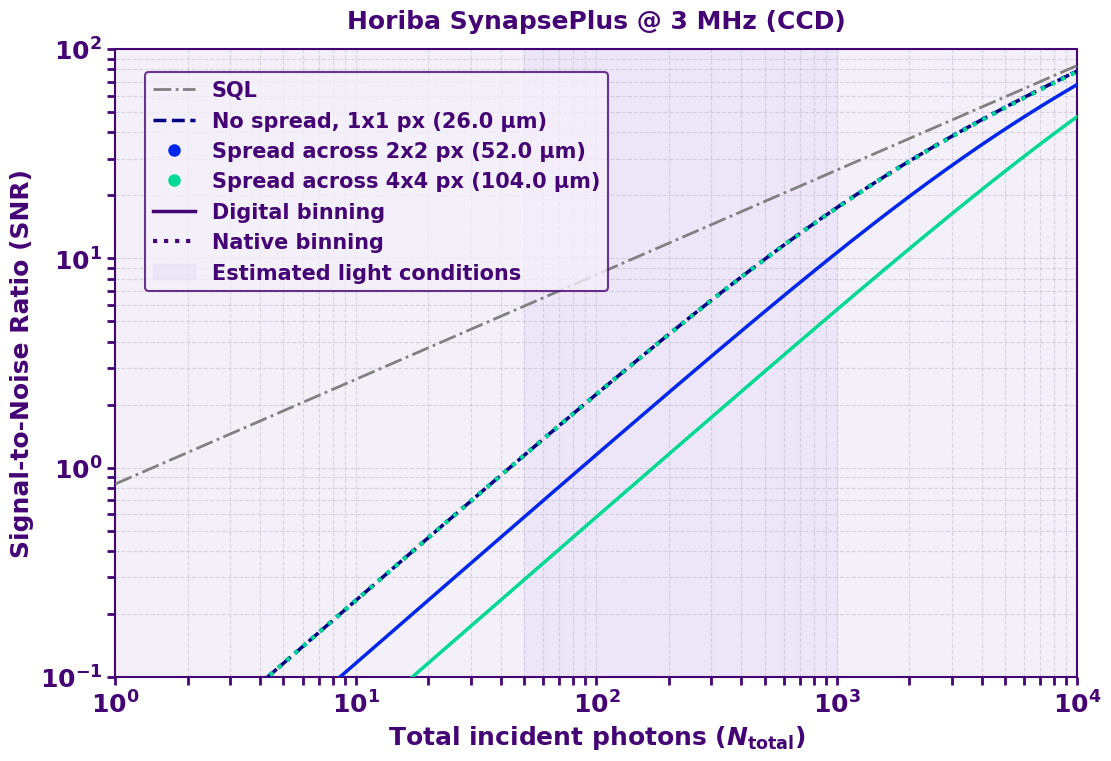

In [6]:
plot_camera_binning_impact(
    camera_key='Horiba_3MHz',
    camera_database=CAMERA_DATABASE,
    show_inset=False
)

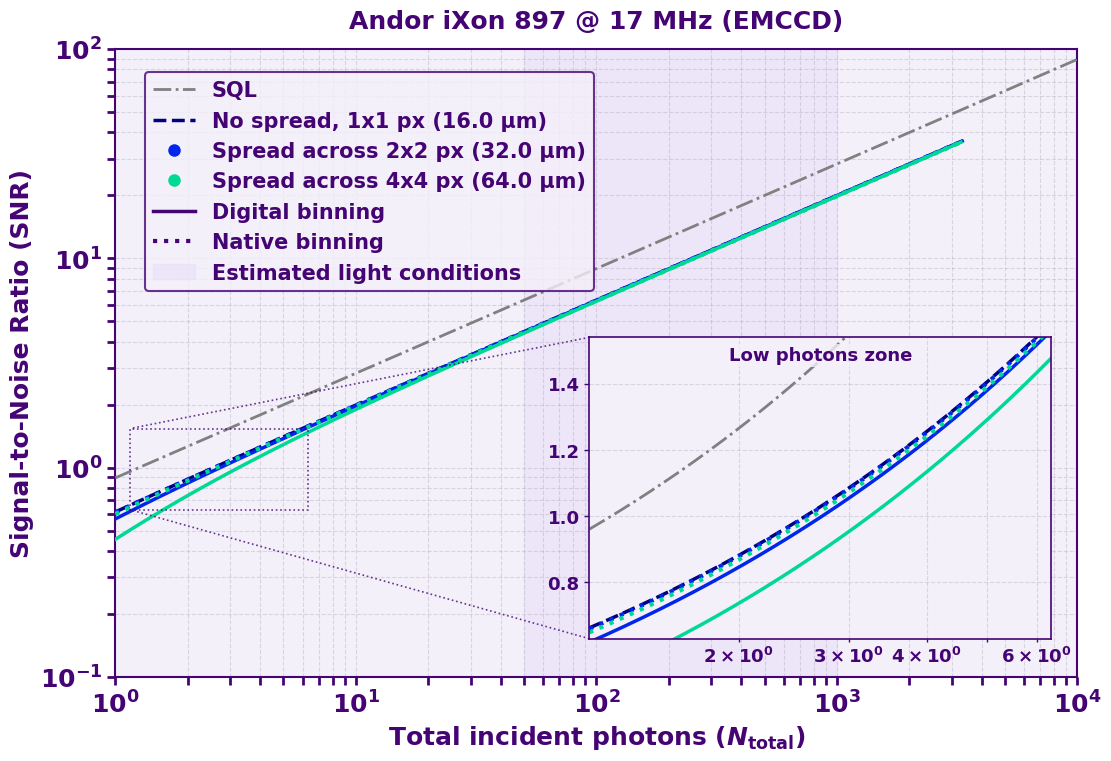

In [7]:
plot_camera_binning_impact(
    camera_key='Andor_17MHz',
    camera_database=CAMERA_DATABASE
    )

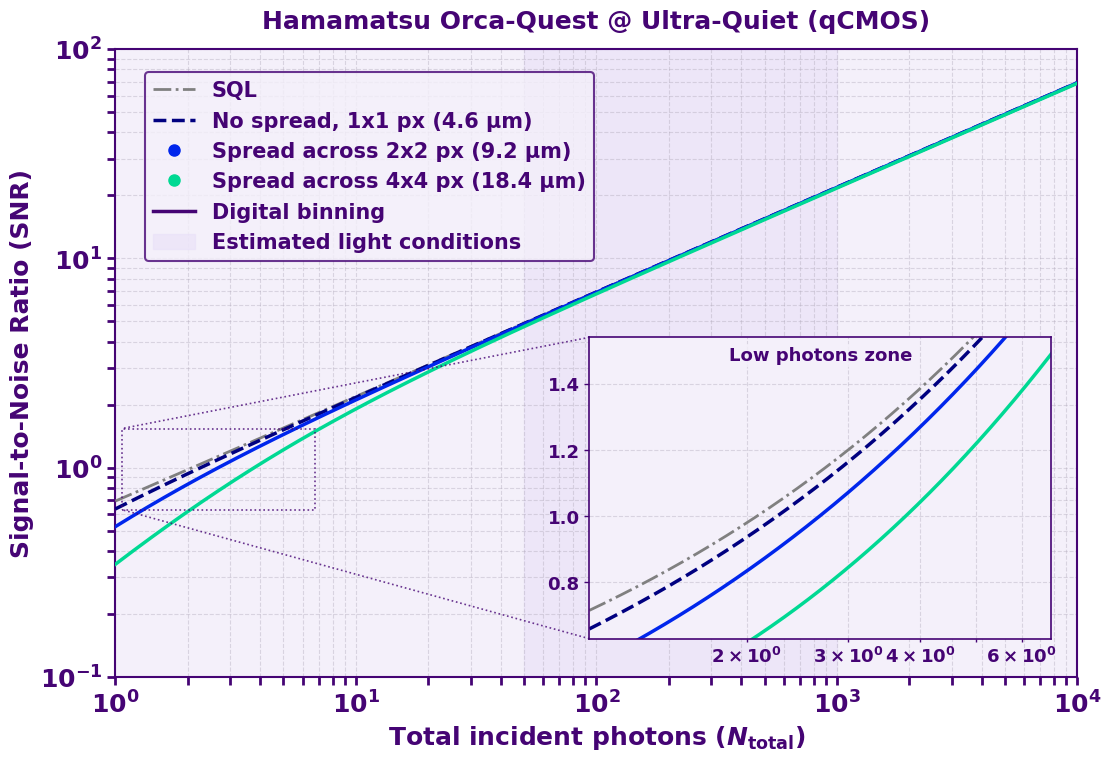

In [8]:
plot_camera_binning_impact(
    camera_key='Hamamatsu_OrcaQuest',
    camera_database=CAMERA_DATABASE
)

In [9]:
def plot_camera_efficiency_performance(camera_key, camera_database, bin_factors=[2, 4], 
                                        bg_fraction=1e-3, dark_fraction=1e-9,
                                        global_em_gain=300, show_inset=True):
    """
    Benchmarks a single camera efficiency against the Standard Quantum Limit (SQL)
    with a fixed high-fidelity inset zone between 200 and 3000 incident photons.
    """
    plt.rcParams.update({
        'axes.labelweight': 'bold', 
        'axes.titleweight': 'bold',
        'font.weight': 'bold'
    })
    main_color = "#450474"
    ideal_color = "navy"
    
    fig, ax = plt.subplots(figsize=(11, 7.5), layout="constrained")
    ax.set_facecolor('#f4f0fa')
    
    # Establish a clean, total incident photon range to drive the simulation safely
    photon_range = np.logspace(0, 5, 5000)
    
    # Inset layout setup conditional on the show_inset flag
    if show_inset:
        ax_ins = inset_axes(ax, width="65%", height="65%", loc="lower right", 
                            bbox_to_anchor=(-0.02, 0.05, 1, 1), bbox_transform=ax.transAxes)
        ax_ins.set_facecolor('#f4f0fa')
    
    # Extract selected camera metadata and specifications
    item = camera_database[camera_key]
    specs = item['specs']
    camera_type = item['type']
    pixel_size = specs['pixel_size']

    # Evaluate the physical Shot Noise Limit based on baseline quantum efficiency
    snr_snl = np.sqrt(specs['qe'] * photon_range)
    
    # The SQL baseline is by definition 100% efficiency
    eff_sql = np.ones_like(photon_range) * 100.0
    ax.plot(photon_range, eff_sql, color='gray', linestyle="-.", lw=2, zorder=3)
    if show_inset:
        ax_ins.plot(photon_range, eff_sql, color='gray', linestyle="-.", lw=2)

    visible_mask = (photon_range >= 1.0) & (photon_range <= 1e4)
    all_eff_curves = []

    # Base case (100% of photons focused on a single pixel, bin=1)
    if camera_type == 'qCMOS':
        snr_base = calculate_qcmos_snr(specs, photon_range, bg_fraction, dark_fraction, bin_factor=1)
    elif camera_type == 'CCD':
        snr_base = calculate_ccd_snr(specs, photon_range, bg_fraction, dark_fraction, bin_factor=1)
    elif camera_type == 'EMCCD':
        snr_base = calculate_emccd_snr(specs, photon_range, global_em_gain, bg_fraction, dark_fraction, bin_factor=1)

    eff_base = (snr_base / snr_snl) * 100.0
    all_eff_curves.append(eff_base[visible_mask])

    ax.plot(photon_range, eff_base, color=ideal_color, linestyle="--", lw=2.5, zorder=4)
    if show_inset:
        ax_ins.plot(photon_range, eff_base, color=ideal_color, linestyle="--", lw=2.5)

    # Setup color mapping for different spatial spread/binning factors
    color_space = np.linspace(0.15, 0.85, len(bin_factors))
    color_handles = []

    # Evaluate performance across each n x n super-pixel configuration
    for idx, n in enumerate(bin_factors):
        super_pixel_size_um = (n * pixel_size) * 1e6
        factor_color = plt.colormaps['winter'](color_space[idx])

        # Digital (software) binning calculation
        if camera_type == 'qCMOS':
            snr_no_bin = calculate_qcmos_snr(specs, photon_range, bg_fraction, dark_fraction, bin_factor=n)
        else:
            snr_no_bin = calculate_no_binning_spread_snr(specs, photon_range, bg_fraction, dark_fraction, bin_factor=n, cam_type=camera_type, global_em_gain=global_em_gain)
        
        eff_no_bin = (snr_no_bin / snr_snl) * 100.0
        all_eff_curves.append(eff_no_bin[visible_mask])
        
        ax.plot(photon_range, eff_no_bin, color=factor_color, linestyle="-", lw=2.5, zorder=4)
        if show_inset:
            ax_ins.plot(photon_range, eff_no_bin, color=factor_color, linestyle="-", lw=2.5)

        # Native (hardware/sensor-level) binning calculation
        if camera_type != 'qCMOS':
            if camera_type == 'CCD':
                snr_with_bin = calculate_ccd_snr(specs, photon_range, bg_fraction, dark_fraction, bin_factor=n)
            elif camera_type == 'EMCCD':
                snr_with_bin = calculate_emccd_snr(specs, photon_range, global_em_gain, bg_fraction, dark_fraction, bin_factor=n)
                
            eff_with_bin = (snr_with_bin / snr_snl) * 100.0
            all_eff_curves.append(eff_with_bin[visible_mask])
            
            ax.plot(photon_range, eff_with_bin, color=factor_color, linestyle=":", lw=3.0, zorder=4)
            if show_inset:
                ax_ins.plot(photon_range, eff_with_bin, color=factor_color, linestyle=":", lw=3.0)

        # Legend handles for pixel spread configurations
        color_handles.append(
            mlines.Line2D([], [], color=factor_color, marker="o", linestyle="None", markersize=7, 
                          label=f"Spread across {n}x{n} px ({super_pixel_size_um:.1f} µm)")
        )

    # Inset axis formatting and range limits
    if show_inset:
        ax_ins.axvspan(50, 1000, color='#e8def8', alpha=0.5, zorder=1)
        ax_ins.set_xlim(45.0, 1100.0)
        ax_ins.set_ylim(96, 100.1)
        ax_ins.grid(True, which="both", ls="--", alpha=0.4, color='#b0a8b9')
        ax_ins.tick_params(axis='both', which='both', labelsize=13, labelcolor=main_color, color=main_color, width=1.0)
        ax_ins.set_xscale('log')
        
        for spine in ax_ins.spines.values():
            spine.set_edgecolor(main_color)
            spine.set_linewidth(1.2)
            
        mark_inset(ax, ax_ins, loc1=2, loc2=1, fc="none", ec=main_color, lw=1.2, ls=":", alpha=0.8, zorder=5)
    
    # Main figure labeling and axes styling
    title_label = f"{item['label']} ({camera_type})"
    ax.set_title(title_label, fontsize=18, color=main_color, pad=15)
    ax.set_xlabel(r'Total incident photons ($N_{\mathrm{total}}$)', fontsize=18, color=main_color, weight='bold')
    ax.set_ylabel('Camera performance relative to SQL (%)', fontsize=18, color=main_color, weight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.4, color='#b0a8b9')
    
    ax.tick_params(axis='both', which='both', labelsize=15, labelcolor=main_color, color=main_color, width=2.0, length=6)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_weight('bold')
        
    ax.set_xscale('log')
    ax.set_xlim(1, 1e4)
    
    try:
        absolute_min_eff = np.nanmin([np.nanmin(curve) for curve in all_eff_curves if len(curve) > 0])
        dynamic_y_min = max(0.0, absolute_min_eff - 5.0)
        if np.isnan(dynamic_y_min) or np.isinf(dynamic_y_min) or dynamic_y_min >= 100.0:
            dynamic_y_min = 50.0
    except ValueError:
        dynamic_y_min = 50.0
    
    ax.set_ylim(dynamic_y_min, 102.0)

    for spine in ax.spines.values():
        spine.set_edgecolor(main_color)
        spine.set_linewidth(1.5)
    
    ax.axvspan(50, 1000, color='#e8def8', alpha=0.5, zorder=1)

    # Figure legend construction
    style_handles = [
        mlines.Line2D([], [], color='gray', linestyle="-.", linewidth=2, label="SQL"),
        mlines.Line2D([], [], color=ideal_color, linestyle="--", linewidth=2.5, label=f"No spread, 1x1 px ({pixel_size*1e6:.1f} µm)"),
        mlines.Line2D([], [], color=main_color, linestyle="-", linewidth=2.5, label="Digital binning")
    ]
    if camera_type != 'qCMOS':
        style_handles.append(mlines.Line2D([], [], color=main_color, linestyle=":", linewidth=3.0, label="Native binning"))
        
    patch_handle = mpatches.Patch(color='#e8def8', alpha=0.5, label='Estimated light conditions')
    all_handles = style_handles[:2] + color_handles + style_handles[2:] + [patch_handle]

    # Target axis selection for legend placement based on inset visibility
    target_ax = ax_ins if show_inset else ax
    legend_loc = 'lower right' if show_inset else 'upper left'
    bbox_anchor = (0.98, 0.02) if show_inset else (0.02, 0.98)
    font_size = 15

    leg = target_ax.legend(
        handles=all_handles, 
        fontsize=font_size, 
        prop={'weight': 'bold', 'size': font_size}, 
        facecolor='#f4f0fa', 
        edgecolor=main_color, 
        loc=legend_loc, 
        bbox_to_anchor=bbox_anchor, 
        ncol=1
    )
    leg.get_frame().set_linewidth(1.2 if show_inset else 1.5)
    for text in leg.get_texts(): 
        text.set_color(main_color)
        
    plt.show()

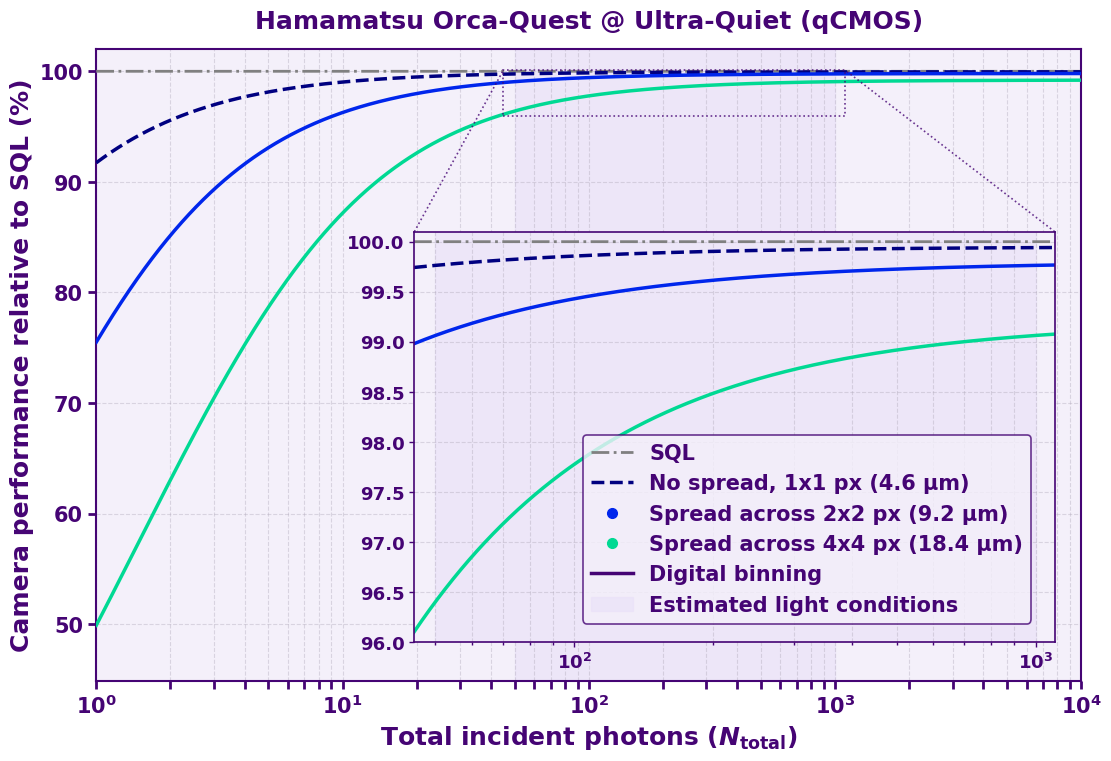

In [10]:
plot_camera_efficiency_performance(
    camera_key='Hamamatsu_OrcaQuest',
    camera_database=CAMERA_DATABASE
)

## Readout fidelity and bimodal distribution overlap.

Evaluating whether an optical tweezer is occupied (Hypothesis $H_1$) or empty (Hypothesis $H_0$) requires projecting our stochastic time-integrated signal onto a physical photoelectron or digital count histogram. Due to the discrete, quantum nature of both the atomic fluorescence and the environmental background scattering, this histogram manifests as a bimodal probability density function. Rather than using standard symmetric Gaussian curves, this physical distribution is simulated using Poissonian statistics to rigorously incorporate the inherent skewness and quantum nature of low-photon counting.

To simulate the exact physical boundaries of these two peaks, we adopt a clean framework that avoids explicit exposure time tracking by mapping the noise scales directly via proportional fractions ($f_{\mathrm{bg}}$ and $f_{\mathrm{dark}}$) relative to the total incident photon range ($N_{\mathrm{photons}}$), matched with the sensor architecture properties under a binning factor $N_{\mathrm{bin}}$. 

Crucially, mapping these background and thermal parameters as fixed fractions of $N_{\mathrm{photons}}$ is an intentional abstraction designed to simplify the mathematical framework without tracking explicit integration times. In this context, $N_{\mathrm{photons}}$ acts as a virtual "reference clock" representing the duration of the experimental window. For the empty trap scenario (Hypothesis $H_0$), no real fluorescence photons are collected; however, $N_{\mathrm{photons}}$ is maintained within the equations as a baseline scaling factor. This allows us to quantify the accumulated dark counts and background scatter over that identical integration window, ensuring strict formal consistency with our pre-established noise definitions while omitting the raw atomic signal contribution from the mean:

* **The left peak** ($H_0$, dark/empty state): Centered at the background floor, its mean value corresponds strictly to the accumulated environmental background and thermal events. Its width is dictated by the background shot noise and the sensor's intrinsic dark and read noise floors:
  $$\mu_0 = \eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2 + N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2$$
  $$\sigma_0^2 = \text{Var}_{\mathrm{sensor}}(H_0)$$

* **The right peak** ($H_1$, bright/atom present state): Centered at the shifted baseline, its mean incorporates the net collected atomic fluorescence flux. Its width is intrinsically broader than the dark state due to the additional Poissonian shot noise injected by the scattering of the $^{87}\text{Rb}$ atom itself:
  $$\mu_1 = \eta_q \cdot N_{\mathrm{photons}} + \eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2 + N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2$$
  $$\sigma_1^2 = \text{Var}_{\mathrm{sensor}}(H_1)$$

To tailor this simulation to our experimental conditions, the background mean $\mu_0$ is modeled using the baseline constraints established in the reference work of Lucas Beguin's thesis. Conversely, the bright signal contribution under $H_1$ is driven by our estimated light conditions, which target a collected signal of approximately 800 photons within a 10 ms integration window. 

The baseline variance $\text{Var}_{\mathrm{sensor}}$ depends strictly on the physical architecture chosen for the sensor matrix. In order to match the exact noise equations utilized across our simulation framework, the variance parameters for each candidate camera type are formulated as follows:

$$\sigma_{\text{CCD}}^2 = (\eta_q \cdot N_{\mathrm{photons}}) + (\eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2) + (N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2) + \sigma_{\text{read}}^2$$

$$\sigma_{\text{EMCCD}}^2 = G^2 \cdot F^2 \cdot \left(\eta_q \cdot N_{\mathrm{photons}} + \eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2 + N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2 + \sigma_{\mathrm{CIC}} \cdot N_{\mathrm{bin}}^2\right) + \sigma_{\text{read}}^2$$

$$\sigma_{\text{qCMOS}}^2 = (\eta_q \cdot N_{\mathrm{photons}}) + (\eta_q \cdot N_{\mathrm{photons}} \cdot f_{\mathrm{bg}} \cdot N_{\mathrm{bin}}^2) + (N_{\mathrm{photons}} \cdot f_{\mathrm{dark}} \cdot N_{\mathrm{bin}}^2) + (\sigma_{\text{read}}^2 \cdot N_{\mathrm{bin}}^2)$$

To discriminate between these two operational states during data acquisition, a decision threshold ($x_{\text{th}}$) is established between the two distribution peaks. Any single-shot measurement falling below $x_{\text{th}}$ is assigned to $H_0$ (empty trap), while any value equal to or greater than $x_{\text{th}}$ is assigned to $H_1$ (atom present). The physical overlap between the statistical tails of these two probability mass functions across $x_{\text{th}}$ establishes the system's operational readout error channels.

The probability of registering a false positive ($\epsilon_{\mathrm{FP}}$)—interpreting a noise fluctuation in an empty trap as an atom—corresponds to the integrated sum of the $H_0$ distribution that leaks to the right of the threshold. Conversely, the probability of a false negative ($\epsilon_{\mathrm{FN}}$)—missing an atom due to low photon collection—corresponds to the sum of the $H_1$ distribution leaking to the left of $x_{\text{th}}$. The global Readout Fidelity is defined as the complement of the total error probability, assuming equal prior probabilities for both operational states:

$$F_{\mathrm{R}} = 1 - \frac{1}{2}\left(\epsilon_{\mathrm{FP}}(x_{\text{th}}) + \epsilon_{\mathrm{FN}}(x_{\text{th}})\right)$$

By simulating this Poissonian profile with our target of ~800 photons against the Beguin thesis background bounds, we can map out the exact readout fidelity limits. This allows us to determine the optimal threshold $x_{\text{th,opt}}$ where the two distributions intersect, minimizing the total error rate under realistic, asymmetric noise conditions.

In [11]:
from scipy import stats

def plot_bimodal_distribution_simulation(camera_key, camera_database, N_photons=800, bin_factor=1,
                                         bg_fraction=1e-3, dark_fraction=1e-9, global_em_gain=500):
    """
    Simulates and plots the asymmetric bimodal Poisson distribution using a broken X-axis.
    Enforces strict physical boundaries (X >= 0) and applies custom amplitude weights
    (25% background vs 75% signal) to match expected laboratory histogram profiles.
    """
    plt.rcParams.update({
        'axes.labelweight': 'bold', 
        'axes.titleweight': 'bold',
        'font.weight': 'bold'
    })
    
    c_dark_violet = "#4A154B"
    c_bright_violet = "#912491"
    c_cyan = "#00BCD4"
    c_dark_cyan = "#00838F"
    
    # Custom amplitude weights to avoid the background peak cannibalizing the signal profile
    w_background = 0.25
    w_signal = 0.75
    
    item = camera_database[camera_key]
    specs = item['specs']
    camera_type = item['type']
    qe = specs['qe']
    read_noise = specs['read_noise']
    
    shared_bg = qe * N_photons * bg_fraction * (bin_factor ** 2)
    shared_dark = N_photons * dark_fraction * (bin_factor ** 2)
    
    if camera_type == 'EMCCD':
        cic_noise = specs.get('cic', 0.0)
        f_sq = (specs.get('excess_noise_factor', 1.414)) ** 2
        mu_0 = global_em_gain * (shared_bg + shared_dark + cic_noise)
        mu_1 = mu_0 + global_em_gain * (qe * N_photons)
        sigma_0 = np.sqrt((global_em_gain ** 2) * f_sq * (shared_bg + shared_dark + cic_noise) + read_noise ** 2)
        sigma_1 = np.sqrt((global_em_gain ** 2) * f_sq * (qe * N_photons + shared_bg + shared_dark + cic_noise) + read_noise ** 2)
    elif camera_type == 'CCD':
        mu_0 = shared_bg + shared_dark
        mu_1 = mu_0 + qe * N_photons
        sigma_0 = np.sqrt(shared_bg + shared_dark + read_noise ** 2)
        sigma_1 = np.sqrt(qe * N_photons + shared_bg + shared_dark + read_noise ** 2)
    elif camera_type == 'qCMOS':
        mu_0 = shared_bg + shared_dark
        mu_1 = mu_0 + qe * N_photons
        sigma_0 = np.sqrt(shared_bg + shared_dark + (read_noise ** 2) * (bin_factor ** 2))
        sigma_1 = np.sqrt(qe * N_photons + shared_bg + shared_dark + (read_noise ** 2) * (bin_factor ** 2))

    # Analytical optimum threshold intersection point
    def intersection_equation(x):
        return (((x - mu_0) ** 2) / (2.0 * (sigma_0 ** 2))) - (((mu_1 - x) ** 2) / (2.0 * (sigma_1 ** 2))) - np.log(sigma_1 / sigma_0)
    
    from scipy.optimize import fsolve
    x_th_opt = int(np.round(fsolve(intersection_equation, [(mu_0 + mu_1) / 2.0])[0]))
    
    # Discrete error mapping based on pure Poisson cumulative distributions
    epsilon_fp = 1.0 - stats.poisson.cdf(x_th_opt - 1, mu_0)
    epsilon_fn = stats.poisson.cdf(x_th_opt - 1, mu_1)
    readout_fidelity = 1.0 - 0.5 * (epsilon_fp + epsilon_fn)
    
    # Generate strict discrete ranges for both peaks (Background floor is clamped tightly at 0)
    x_range_0 = np.arange(0, int(mu_0 + 4.0 * sigma_0) + 1)
    x_range_1 = np.arange(max(0, int(mu_1 - 4.0 * sigma_1)), int(mu_1 + 4.0 * sigma_1) + 1)
    
    # Compute Poisson PMFs scaled directly by the experimental histogram weights
    pmf_0 = w_background * stats.poisson.pmf(x_range_0, mu_0)
    pmf_1 = w_signal * stats.poisson.pmf(x_range_1, mu_1)
    
    # Create subplots sharing the Y axis for the broken layout
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(11, 6.5))
    fig.patch.set_facecolor('white')
    ax1.set_facecolor('#f4f0fa')
    ax2.set_facecolor('#f4f0fa')
    
    # --- Plot Left Panel (H0 - Fondo Clamped at X>=0) ---
    ax1.plot(x_range_0, pmf_0, color=c_dark_cyan, lw=3.0, label=r'Empty tweezer $H_0$ (Fondo)')
    mask_fp = x_range_0 >= x_th_opt
    ax1.fill_between(x_range_0, pmf_0, where=mask_fp, color=c_cyan, alpha=0.3, label=r'False positives $\epsilon_{\mathrm{FP}}$')
    if x_range_0[0] <= x_th_opt <= x_range_0[-1]:
        ax1.axvline(x_th_opt, color=c_dark_violet, linestyle='-', lw=2.5, zorder=5)
        
    # --- Plot Right Panel (H1 - Signal) ---
    ax2.plot(x_range_1, pmf_1, color=c_bright_violet, lw=3.0, label=r'Atom present $H_1$ (Señal + Fondo)')
    mask_fn = x_range_1 < x_th_opt
    ax2.fill_between(x_range_1, pmf_1, where=mask_fn, color=c_bright_violet, alpha=0.15, label=r'False negatives $\epsilon_{\mathrm{FN}}$')
    if x_range_1[0] <= x_th_opt <= x_range_1[-1]:
        ax2.axvline(x_th_opt, color=c_dark_violet, linestyle='-', lw=2.5, zorder=5, label=f'Threshold $x_{{th,opt}} = {x_th_opt}$')

    # Set strict physical boundaries to prevent sub-zero distribution leaks
    ax1.set_xlim(0, mu_0 + 4.0 * sigma_0)
    ax2.set_xlim(mu_1 - 4.0 * sigma_1, mu_1 + 4.0 * sigma_1)
    
    # Hide spines between subplots to simulate the cut
    ax1.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax1.yaxis.tick_left()
    ax2.yaxis.tick_right()
    ax2.tick_params(labelright=False)
    
    # Global aesthetics and borders
    for ax in [ax1, ax2]:
        ax.grid(True, which="both", ls="--", alpha=0.4, color='#b0a8b9')
        ax.tick_params(axis='both', which='both', labelsize=11, labelcolor=c_dark_violet, color=c_dark_violet, width=1.5)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_weight('bold')
        for spine_key, spine in ax.spines.items():
            spine.set_edgecolor(c_dark_violet)
            spine.set_linewidth(1.5)

    # Broken axis diagonal cut marks
    d = .015
    kwargs = dict(transform=ax1.transAxes, color=c_dark_violet, clip_on=False, lw=1.5)
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)        
    ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  

    kwargs.update(transform=ax2.transAxes)
    ax2.plot((-d, +d), (-d, +d), **kwargs)        
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  

    # Shared global labels and titles via figure mapping
    fig.suptitle(f"{item['label']} ({camera_type})  |  N = {N_photons} photons  |  Fidelity = {readout_fidelity * 100:.5f}%", 
                 fontsize=13, color=c_dark_violet, weight='bold', y=0.98)
    
    fig.supxlabel('Digital counts / Photoelectrons', fontsize=12, color=c_dark_violet, y=0.02, weight='bold')
    ax1.set_ylabel('Weighted probability mass', fontsize=12, color=c_dark_violet, weight='bold')
    
    # Unify legends across both distinct axes without duplication
    handles, labels = [], []
    for ax in [ax1, ax2]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    by_label = dict(zip(labels, handles))
    
    leg = ax2.legend(by_label.values(), by_label.keys(), fontsize=10, prop={'weight':'bold'}, 
                     facecolor='#f4f0fa', edgecolor=c_dark_violet, loc='upper right')
    leg.get_frame().set_linewidth(1.5)
    for text in leg.get_texts(): 
        text.set_color(c_dark_violet)
        
    plt.subplots_adjust(wspace=0.08)
    plt.show()

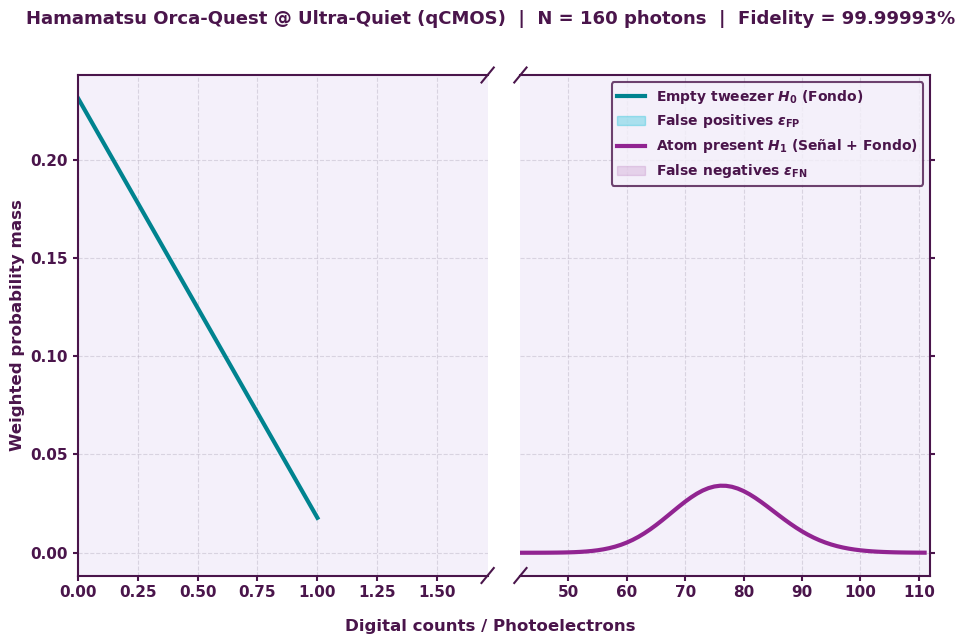

In [12]:
plot_bimodal_distribution_simulation(
    camera_key='Hamamatsu_OrcaQuest',
    camera_database=CAMERA_DATABASE,
    N_photons=160
)